Training pix2pix cGAN on cuda... Running 10 epochs for demonstration.
Epoch [1/10] | Loss D: 0.3408 | Loss G: 31.2258
Epoch [2/10] | Loss D: 0.2070 | Loss G: 24.8458
Epoch [3/10] | Loss D: 0.1252 | Loss G: 22.9819
Epoch [4/10] | Loss D: 0.0886 | Loss G: 21.9552
Epoch [5/10] | Loss D: 0.0463 | Loss G: 21.8273
Epoch [6/10] | Loss D: 0.0358 | Loss G: 21.5729
Epoch [7/10] | Loss D: 0.0248 | Loss G: 21.6947
Epoch [8/10] | Loss D: 0.0189 | Loss G: 21.7949
Epoch [9/10] | Loss D: 0.0154 | Loss G: 21.7429
Epoch [10/10] | Loss D: 0.0149 | Loss G: 21.7010

Training Complete! Saving demonstration results...


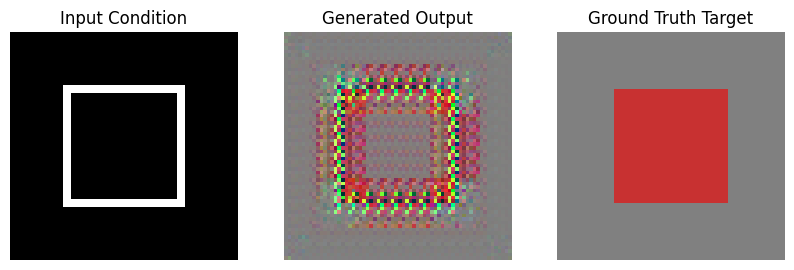

In [1]:
# 1. Install necessary libraries
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# 2. Simple Mock Dataset representing Sketch -> Color Image Pairs
# Creating synthetic square pairs to make the script standalone and lightning-fast
class MockPix2PixDataset(Dataset):
    def __init__(self, size=100):
        self.size = size
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        # Create a mock target image (e.g., colorful square)
        target = np.ones((64, 64, 3), dtype=np.uint8) * 128
        target[16:48, 16:48, :] = [200, 50, 50] # Red square center

        # Create a mock input condition (e.g., black and white sketch outline)
        condition = np.zeros((64, 64, 3), dtype=np.uint8)
        condition[15:17, 15:49, :] = 255
        condition[47:49, 15:49, :] = 255
        condition[15:49, 15:17, :] = 255
        condition[15:49, 47:49, :] = 255

        return self.transform(condition), self.transform(target)

# 3. Define a basic pix2pix Generator (Encoder-Decoder Structure)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# 4. Define a basic pix2pix Discriminator (Takes Condition + Target Pair)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Takes 6 channels total (3 from condition image + 3 from target/generated image)
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 1, 4, 2, 1), nn.Sigmoid()
        )
    def forward(self, cond, img):
        x = torch.cat([cond, img], dim=1)
        return self.model(x)

# 5. Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = MockPix2PixDataset()
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

netG = Generator().to(device)
netD = Discriminator().to(device)

criterionBCE = nn.BCELoss()
criterionL1 = nn.L1Loss() # pix2pix uses L1 loss to enforce structural similarity

optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))

print(f"Training pix2pix cGAN on {device}... Running 10 epochs for demonstration.")

# 6. Adversarial Training Loop
for epoch in range(10):
    for i, (condition_img, target_img) in enumerate(dataloader):
        condition_img, target_img = condition_img.to(device), target_img.to(device)
        batch_size = condition_img.size(0)

        # --- Train Discriminator ---
        optimizerD.zero_grad()

        # Real Pair Loss
        output_real = netD(condition_img, target_img)
        loss_D_real = criterionBCE(output_real, torch.ones_like(output_real))

        # Fake Pair Loss
        fake_img = netG(condition_img)
        output_fake = netD(condition_img, fake_img.detach())
        loss_D_fake = criterionBCE(output_fake, torch.zeros_like(output_fake))

        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizerD.step()

        # --- Train Generator ---
        optimizerG.zero_grad()

        output_g_fake = netD(condition_img, fake_img)
        loss_G_gan = criterionBCE(output_g_fake, torch.ones_like(output_g_fake))
        loss_G_L1 = criterionL1(fake_img, target_img) * 100 # Lambda weight = 100

        loss_G = loss_G_gan + loss_G_L1
        loss_G.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/10] | Loss D: {loss_D.item():.4f} | Loss G: {loss_G.item():.4f}")

print("\nTraining Complete! Saving demonstration results...")

# 7. Visualize Results
condition_img, target_img = next(iter(dataloader))
with torch.no_grad():
    fake_img = netG(condition_img.to(device)).cpu()

def denormalize(tensor):
    return ((tensor + 1) / 2).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(denormalize(condition_img[0]))
axes[0].set_title("Input Condition")
axes[0].axis("off")

axes[1].imshow(denormalize(fake_img[0]))
axes[1].set_title("Generated Output")
axes[1].axis("off")

axes[2].imshow(denormalize(target_img[0]))
axes[2].set_title("Ground Truth Target")
axes[2].axis("off")

plt.savefig("cgan_output.png")
plt.show()